# Quantum Simulator — Walkthrough

A guided tour of the `qsim` package: states, gates, circuits, measurement, visualization, and a handful of textbook algorithms.

**Convention:** qubit 0 is the most-significant bit of the basis-state label. For 3 qubits, `|011>` means q0=0, q1=1, q2=1, which has integer index 3.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt

from qsim import QuantumCircuit, QuantumState, gates, algorithms
from qsim.visualization import plot_histogram, plot_bloch, plot_state_city

## 1. Single-qubit superposition

In [2]:
qc = QuantumCircuit(1).h(0)
print('state         :', qc.state.pretty())
print('probabilities :', qc.probability_dict())
print(qc)

state         : +0.7071|0> +0.7071|1>
probabilities : {'0': 0.4999999999999999, '1': 0.4999999999999999}
q0: -H-


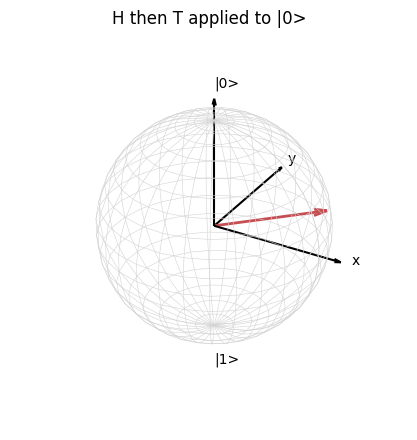

In [3]:
# Bloch sphere
qc = QuantumCircuit(1).h(0).t(0)
fig = plot_bloch(qc.state, title='H then T applied to |0>')
plt.show()

## 2. Entanglement — a Bell pair

q0: -H-@-
q1: ---X-
amplitudes : +0.7071|00> +0.7071|11>
1024 shots : {'00': 510, '11': 514}


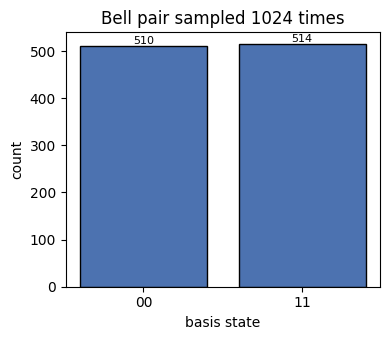

In [4]:
qc = QuantumCircuit(2).h(0).cnot(0, 1)
print(qc)
print('amplitudes :', qc.state.pretty())
counts = qc.sample(1024)
print('1024 shots :', counts)
fig = plot_histogram(counts, title='Bell pair sampled 1024 times')
plt.show()

## 3. GHZ state amplitudes

q0: -H-@-@-
q1: ---X-|-
q2: -----X-
amplitudes: +0.7071|000> +0.7071|111>


D:\Alex University\QC\proj\qsim\visualization.py:135: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


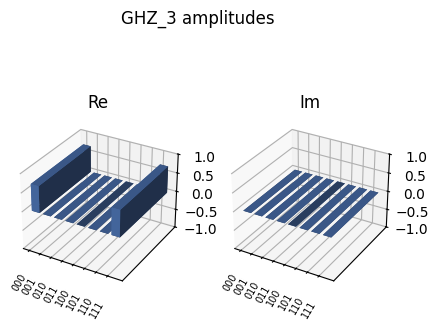

In [5]:
qc = algorithms.ghz(3)
print(qc)
print('amplitudes:', qc.state.pretty())
fig = plot_state_city(qc.state, title='GHZ_3 amplitudes')
plt.show()

## 4. Quantum teleportation

Send an arbitrary single-qubit state from qubit 0 to qubit 2 using a shared Bell pair and two classical bits.

In [6]:
rng = np.random.default_rng(0)
payload = np.array([0.6, 0.8j], dtype=complex)
payload = payload / np.linalg.norm(payload)
qc, m0, m1, bob = algorithms.teleport(payload, rng)
print('Alice payload :', payload)
print('classical bits:', m0, m1)
print('Bob receives  :', bob)
print('fidelity      :', abs(np.vdot(payload, bob)) ** 2)

Alice payload : [0.6+0.j  0. +0.8j]
classical bits: 1 0
Bob receives  : [0.6+0.j  0. +0.8j]
fidelity      : 1.0


## 5. Deutsch–Jozsa

Decide whether $f:\{0,1\}^n \to \{0,1\}$ is constant or balanced in a **single** oracle query.

In [ ]:
n = 4
cases = {
    'constant 0':          lambda x: 0,
    'constant 1':          lambda x: 1,
    'first-bit balanced':  lambda x: (x >> (n - 1)) & 1,
    'parity balanced':     lambda x: bin(x).count('1') & 1,
}
for label, fn in cases.items():
    verdict, _ = algorithms.deutsch_jozsa(fn, num_input_qubits=n)
    print(f'{label:24s} -> {verdict}')

## 6. Grover's search

q0: -H-------Oracle-Diffuser-Oracle-Diffuser-Oracle-Diffuser-
q1: ---H-------#-------#-------#-------#-------#-------#-----
q2: -----H-----#-------#-------#-------#-------#-------#-----
q3: -------H---#-------#-------#-------#-------#-------#-----


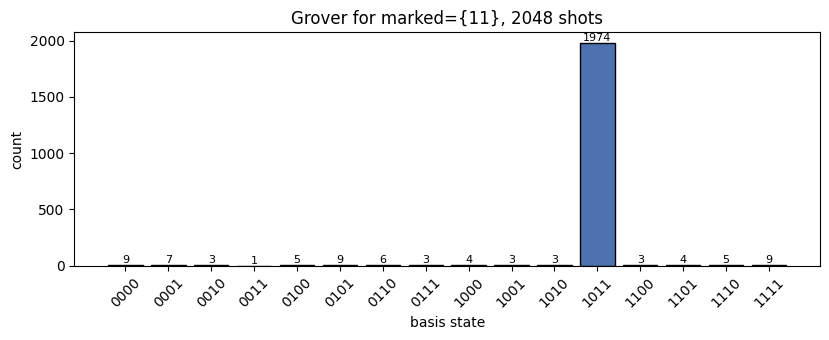

In [7]:
qc = algorithms.grover(marked=[11], num_qubits=4)
print(qc)
counts = qc.sample(2048)
fig = plot_histogram(counts, title='Grover for marked={11}, 2048 shots')
plt.show()

## 7. Quantum Fourier Transform vs. exact matrix

In [8]:
n = 3
M = algorithms.qft_matrix(n)
qc = QuantumCircuit(n)
v = np.zeros(2 ** n, dtype=complex)
v[1] = 1  # |001>
qc.state.vec = v.copy()
qc.compose(algorithms.qft(n))
print('circuit output:', qc.state.vec)
print('matrix output :', M @ v)
print('equal?         ', np.allclose(qc.state.vec, M @ v))

circuit output: [ 3.53553391e-01+0.j          2.50000000e-01+0.25j
  2.16489014e-17+0.35355339j -2.50000000e-01+0.25j
 -3.53553391e-01+0.j         -2.50000000e-01-0.25j
 -2.16489014e-17-0.35355339j  2.50000000e-01-0.25j      ]
matrix output : [ 0.35355339+0.j          0.25      +0.25j        0.        +0.35355339j
 -0.25      +0.25j       -0.35355339+0.j         -0.25      -0.25j
  0.        -0.35355339j  0.25      -0.25j      ]
equal?          True
